In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import pickle

with open('./data/processed/team_matches.pkl', 'rb') as f:
    team_matches = pickle.load(f)
                 
with open('./data/raw/european_leagues_data.pkl', 'rb') as f:
    all_matches = pickle.load(f)

In [3]:
def get_outliers(df, col):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    mask = (df[col] < lower) | (df[col] > upper)
    outlier_df = df[mask].copy()
    outlier_arr = outlier_df[col].to_numpy()

    return outlier_df, outlier_arr

In [4]:
all_matches.keys()

dict_keys(['Serie_A', 'Premier_League', 'La_Liga', 'Bundesliga', 'Ligue_1'])

In [5]:
df_serie_a = all_matches['Serie_A']
df_premier_league = all_matches['Premier_League']
df_la_liga = all_matches['La_Liga']
df_bundesliga = all_matches['Bundesliga']

In [6]:
df_serie_a.shape[0]

5625

In [7]:
df_serie_a.columns

Index(['Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'HTHG', 'HTAG',
       'HTR', 'HF', 'AF', 'HY', 'AY', 'HR', 'AR', 'HS', 'AS', 'HST', 'AST',
       'HC', 'AC', 'season'],
      dtype='str')

In [8]:
df_outlier, outlier_arr = get_outliers(df_serie_a, 'HY')
df_outlier[['Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'HY', 'AY']] 

,Date,HomeTeam,AwayTeam,FTHG,FTAG,HY,AY
826,10/12/2023,Salernitana,Bologna,1.0,2.0,7.0,2.0
849,23/12/2023,Roma,Napoli,2.0,0.0,7.0,4.0
1255,29/01/2023,Milan,Sassuolo,2.0,5.0,7.0,4.0
1751,10/04/2022,Venezia,Udinese,1.0,2.0,7.0,2.0
1839,30/09/2020,Lazio,Atalanta,1.0,4.0,7.0,2.0
2044,21/02/2021,Parma,Udinese,2.0,2.0,7.0,4.0
4930,07/10/12,Siena,Juventus,1.0,2.0,7.0,3.0


In [11]:
team_matches.columns

Index(['season', 'date', 'team', 'opponent', 'yellow_cards', 'red_cards',
       'fouls_committed', 'fouls_received', 'shots', 'shots_opponent',
       'shots_on_target', 'shots_on_target_opponent', 'corners',
       'corners_opponent', 'goals_scored', 'goals_conceded', 'match_result',
       'venue', 'team_result', 'league'],
      dtype='str')

# L'Inter e gli Outlier

## Premessa

Questo notebook sara' pieno di premesse, mani avanti e tanti tentativi di spiegare, in maniera intuitiva, concetti che stanno entrando nel lessico comune ma che spesso possono procurare fraintendimenti su come si interpretano. 

La premessa piu' importante, per quanto mi riguarda, parte da un fatto personale. Ho un Dottorato di Ricerca in Scienze Computazionali e Informatiche e la mia tesi di dottorato non sarebbe stata mai scritta se non ci fosse stato l'aiuto determinante del Professore Bruno Siciliano e del suo Prisma Lab. Spesso non riconosciamo i colpi di fortuna che ci capitano nella vita, uno di questi e' stata la possibilita' di poter conoscere il professor Siciliano e, per un breve periodo, addirittura aver collaborato con il suo gruppo. 

Detto questo, quando qualcuno tira in ballo i fatti citando numeri e statistiche, mi incuriosisco e cerco di capire su quali fatti si possano basare alcune affermazioni. E vista la stima e riconoscenza che ho verso il professor Siciliano, sono stato attirato da un titolo della testata tuttonapoli.net che citava ["Prof. Siciliano: "5 punti recuperati all'Inter, ma c'e' un rimpianto. E' stato uno scandalo!"](https://www.tuttonapoli.net/radio-tutto-napoli/prof-siciliano-5-punti-recuperati-all-inter-ma-c-e-un-rimpianto-e-stato-uno-scandalo-639256). Riporto dall'articolo una frase:

> **Ci sono anche dati statistici su questo tema?** 
> "Si, le statistiche dicono che l'Inter e' la squadra con meno cartellini gialli e 
> meno cartellini rossi. 
> La statistica piu' interessante e' il rapporto tra numero di falli fatti 
> e cartellini distribuiti: 
> mentre il valore medio e' un cartellino ogni quattro falli, 
> l'Inter prende un cartellino giallo ogni otto falli e mezzo. I numeri non mentono".

Ascoltando poi il podcast, il professor Siciliano cita anche che il dato sarebbe un "outlier".  A questo punto, la mia coda di avvocato del diavolo ha iniziato a scondinzolare (si, sono un diavolo avvocato del diavolo. Ad alcuni di noi diavoli ci e' stata data la possibilita' di scegliere tra le corna e la coda, e ho pensato che la coda fosse piu' facile da nascondere e potesse anche essere piu' utile in alcune situazioni) e mi sono messo alla ricerca dei dati che potessero confermare l'affermazione del professore.

Quando si fa un'analisi dati e si studia un'affermazione, prima di tutto si parte dall'affermazione stessa. Sia il podcast che il testo riportato non sono univocamente precisi, come ci si aspetta da un'intervista che ha carattere generale e non specifico, e quando si parla di falli fatti e cartellini distribuiti non e' univoco ma almeno abbiamo un punto di partenza: ***"l'Inter prende un cartellino giallo ogni otto falli e mezzo mentre il valore medio e' un cartellino ogni quattro falli"***. 

Dato che a me piace partire facile, allora mi sono concentrato su uno studio abbastanza semplice: il rapporto tra cartellini ricevuti e falli fatti. "Partire facile" e' sempre relativo, dato che anche un obiettivo che sembra lineare e semplice porta alcuni caveat. Nell'analisi dati, o Data Science, vige la regola zero che e' "garbage in, garbage out": se si fa un'analisi con dati che non sono buoni o non ben definiti, il risultato sara' spazzatura. Aggiungo che spesso le analisi dei dati, i modelli che si introducono, amplificano il risultato e anche dei dati parzialmente sbagliati o non attinenti, possono venire amplificati nelle conclusioni che risulteranno quindi piu' simili a una discarica che a un bidone dell'immondizia.

E a questo punto, c'e' un'altra premessa e mi piace chiarirla dall'inizio. Il vero scopo di questo notebook non e' dare ragione al Professor Siciliano o meno, ma di propormi come il Barbero dell'Analisi Dati, ossia quello che, con fare bonaccione, ti spiega le cose facendoti appassionare su di un argomento del quale, 10 minuti prima, non ti interessava per nulla, tipo la forma delle maniglie nella Firenze dei Medici, e dopo averlo ascoltato ti metti il monocolo e cambi tutte le porte di casa. Ma, a differenza di Barbero, io parlero' di concetti matematici e statistici e, me ne rendo conto, sono argomenti che e' difficile rendere entusiasmanti. Nei prossimi paragrafi scrivero' di cose che, personalmente, trovo interessanti, divertenti, esaltanti ma gia' so che la maggior parte delle persone rimarra' esaltata come a un congresso di Potere al Popolo (un saluto a tutti gli amici di Potere al Popolo). Eppure nel calcio si parla tanto di statistica, di dati e ho il sospetto che spesso si faccia finta di capire. Per cui l'obiettivo finale di questo articolo sara' principalmente spiegare in termini quanto piu' semplici, ma accurati scientificamente, alcuni concetti di base che spesso sento in conversazioni e articoli sul calcio.

## Un outlier non e' una vibrazione

Se si ascolta l'intervista al professor Siciliano, a un certo punto viene menzionato il termine "outlier". Un outlier, per definizione statistica, e' un dato che *differisce significativamente* dagli altri dati osservati. Ci possono essere diverse cause per un outlier e, in genere, quando si fa uno studio statistico dei dati, uno dei primi passi e', appunto, cercare gli outlier nei dati. Non esiste un'unica definizione universalmente accettata di cosa renda un dato un outlier, ma ci sono metodi operativi precisi per individuarli. Quello piu' usato e' quello che si basa sul cosiddetto Scarto Interquartile: ossia la differenza tra il primo e il terzo quartile (Il primo quartile viene indicato con Q1, il terzo con Q3.). Si definiscono outlier i valori che cadono al di sotto del primo quartile meno *k* volte questa differenza, oppure al di sopra del terzo quartile piu' *k* volte la stessa differenza. Il valore standard di *k* e' 1.5, proposto da John Tukey negli anni '70, e corrisponde approssimativamente a escludere i valori oltre 2.7 deviazioni standard dalla media in una distribuzione normale (i famosi 3 sigma che si citano spesso). Io che l'ho scritto mi sono annoiato e, se il mio scopo era quello di essere il nuovo Barbero, so gia' di aver perso dopo aver parlato di "quartile". Per dare un'idea grossolana di quartile, sono le fette di dati che contengono un quarto di dati dopo che questi sono stati ordinati. Prima di tutto guardiamo come sono distribuiti i dati attraverso un istogramma, poi useremo il box-plot per visualizzare quartili e outlier.  

Dato che stiamo parlando del numero di falli fischiati in una partita, prendiamo ad esempio i dati relativi a tutte le partite giocate nel campionato di Serie A dalla stagione 2011/12 fino a fine marzo 2026, oltre 5000 partite, e consideriamo il numero di falli commesso dalla squadra che giocava in casa. Ci saranno partite nelle quali l'arbitro avra' fischiato pochi falli, altre nelle quali il numero e' stato elevato. Contiamo ora il numero di partite nelle quali sono stati fischiati, alla squadra di casa, $x$ numero di falli e costruiamo l'istogramma dei dati.    

Text(0, 0.5, 'Numero di partite')

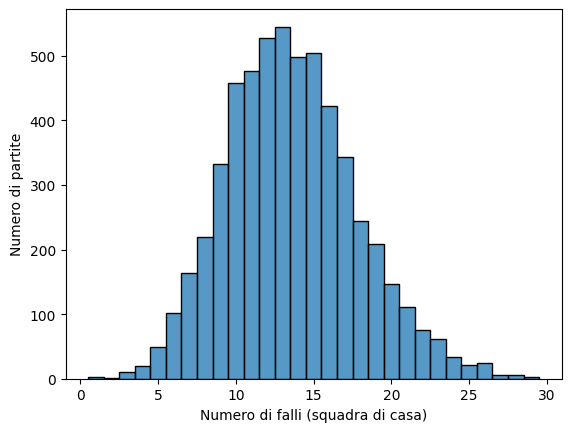

In [44]:
sns.histplot(data=df_serie_a, x='HF', bins=13, discrete=True)
plt.xlabel('Numero di falli (squadra di casa)')
plt.ylabel('Numero di partite')


L'asse $x$ dell'istogramma rappresenta il numero di falli fischiati, l'asse $y$ il numero di partite dove quel numero di falli e' stato registrato. L'istogramma dei dati ci dice, ad esempio, che in oltre 500 partite, il numero di falli fischiati alla squadra di calcio e' stato di 13. Se andiamo a contare il numero di partite in cui sono stati fischiati 5 falli, approssimativamente abbiamo meno di 50 partite; partite nelle quali sono stati fischiati 25 falli sono ancora piu' rare, dal grafico direi che siamo nell'ordine di una ventina. L'istogramma ci visualizza la distribuzione dei dati (ci sono delle ragioni per le quali la forma della distribuzione ci sembra familiare e alcune di queste ragioni sono il motivo per il quale il calcio e' cosi' seguito e amato. Dettagli in seguito), ma poco ci dice su quali siano gli outlier, ossia i valori che si discostano significativamente dal comportamento centrale dei dati, secondo la definizione che abbiamo dato prima. Il box-plot lo visualizza meglio: 

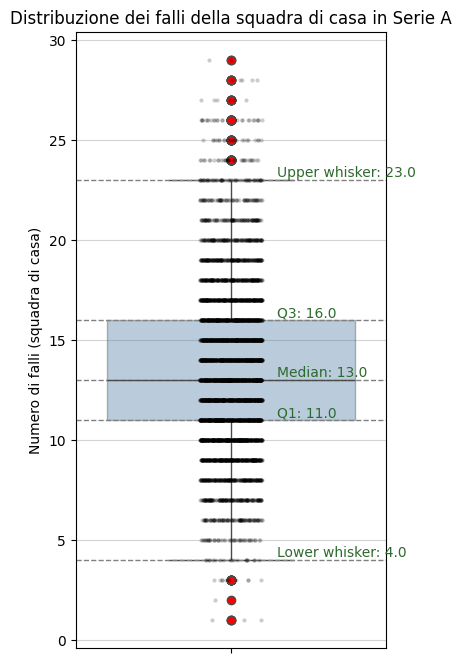

In [43]:
col = 'HF'

q1 = df_serie_a[col].quantile(0.25)
q3 = df_serie_a[col].quantile(0.75)
iqr = q3 - q1
median = df_serie_a[col].median()
lower_whisker = df_serie_a[col][df_serie_a[col] >= q1 - 1.5 * iqr].min()
upper_whisker = df_serie_a[col][df_serie_a[col] <= q3 + 1.5 * iqr].max()

fig, ax = plt.subplots(figsize=(4, 8))

ax.yaxis.grid(True, color='lightgrey', zorder=0)
ax.set_axisbelow(True)

sns.boxplot(
    data=df_serie_a,
    y=col,
    color = 'steelblue',
#    saturation=0.4,
    flierprops=dict(marker='o', color='red', markerfacecolor='red', markersize=6),
    ax=ax
)

for patch in ax.patches:
    patch.set_alpha(0.4)

sns.stripplot(
    data=df_serie_a,
    y=col,
    color='black',
    size=3,
    alpha=0.2,
    ax=ax
)

line_props = dict(color='grey', linestyle='--', linewidth=1)
labels = [
    (lower_whisker, f'Lower whisker: {lower_whisker:.1f}'),
    (q1,            f'Q1: {q1:.1f}'),
    (median,        f'Median: {median:.1f}'),
    (q3,            f'Q3: {q3:.1f}'),
    (upper_whisker, f'Upper whisker: {upper_whisker:.1f}'),
]

for val, label in labels:
    ax.axhline(val, **line_props)
    ax.text(0.65, val, label, transform=ax.get_yaxis_transform(),
            fontsize=10, color='#2d6a2d', va='bottom')


ax.set_title('Distribuzione dei falli della squadra di casa in Serie A')
ax.set_ylabel('Numero di falli (squadra di casa)');


Il box-plot ci visualizza intuitivamente alcuni dei concetti che ho introdotto precedentemente. Q1 e Q3 sono il primo e terzo quartile, e in blu e' visualizzata la parte di dati contenuta tra queste due fette. I whisker inferiore e superiore sono quelli ottenuti moltiplicando 1.5 volte la differenza e, in parole povere, ci dicono dove la stragrande maggioranza di dati si trova. In rosso sono evidenziati, appunto, gli outlier di questa distribuzione. Ci dicono che al di sotto di 4 falli e al di sopra di 23 falli si sono registrati gli "eventi eccezionali", ossia che si discostano di molto da quello che e' il comportamento generale sul numero di falli.

In [37]:
outliers_hf, list_outliers = get_outliers(df_serie_a,
             'HF')

print(f" Numero di outlier: {outliers_hf.shape[0]}, rappresentano il {outliers_hf.shape[0] / df_serie_a.shape[0] * 100:.2f}% del totale.")

 Numero di outlier: 109, rappresentano il 1.94% del totale.


Quindi su oltre 5000 partite, 109 rappresentano dei dati anomali (spesso il concetto di outlier e anomalie viene usato in maniera interscambiabile). E in effetti, a volte questi dati anomali possono nascondere dei problemi. Studiando proprio il numero di falli commesso in una parita, mi sono imbattuto su quattro partite in cui non era stato fischiato nemmeno un fallo a una delle due squadre. Le partite sono:

- [Chelsea - West Ham](https://www.espn.co.uk/football/matchstats/_/gameId/541714)
- [Wolves - Brighton](https://www.espn.co.uk/football/matchstats/_/gameId/513490)
- [Malaga - Real Sociedad](https://www.espn.co.uk/football/matchstats/_/gameId/490376) â€” zero fouls but one yellow card, likely for time-wasting
- [Lille - Rennes](https://www.espn.com/soccer/matchstats/_/gameId/609158) **data inconsistency**issued

Andando a controllare sul sito di espn, ho effettivamente riscontrato che nelle prime 3 partite, una delle due squadre non aveva commesso nemmeno un fallo. Nella partita Malaga-Real Sociedad, inoltre, la squadra ospite non aveva commesso nessun fallo e aveva anche ricevuto un cartellino giallo (per perdita di tempo). Solo Lille-Rennes ha evidenziato un errore nei dati riportati dal sito football-data.co.uk li dove espn riporta un numero di falli superiore. 

Quindi lo studio degli outlier ha evidenziato che avere partite nelle quali non si fischiano falli a una delle due squadre sia possibile. Improbabile, ma possibile. E anche ha evidenziato un errore nella rilevazione dei dati.

Volendo riassumere, possiamo definire gli outlier come anomalie, dati che si discostano di parecchio da quello che e' il comportamento degli altri dati. Non sempre sono errori nella rilevazione, e, anzi, sono spesso casi rarissimi ma reali. Voglio precisare che, comunque, il "parecchio" e' qualcosa che decidiamo noi una volta che usiamo il metodo per rilevare gli outlier, che puo' cambiare a seconda della distribuzione e dal tipo di analisi che vogliamo condurre. l numero di outlier dipende da come sono distribuiti i dati: nel caso del numero di falli, abbiamo trovato 109 outlier su oltre 5000 partite, circa il 2%. In altre distribuzioni la percentuale cambia, ma rimane sempre una frazione piccola del totale (altrimenti non sarebbero outlier).